In [14]:
import pandas as pd

cab_df = pd.read_csv('../data/cab_rides.csv')
weather_df = pd.read_csv('../data/weather.csv')

print("Cab rides shape:", cab_df.shape)
print(cab_df.head())
print("\nWeather shape:", weather_df.shape)
print(weather_df.head())

Cab rides shape: (693071, 10)
   distance cab_type     time_stamp    destination            source  price  \
0      0.44     Lyft  1544952607890  North Station  Haymarket Square    5.0   
1      0.44     Lyft  1543284023677  North Station  Haymarket Square   11.0   
2      0.44     Lyft  1543366822198  North Station  Haymarket Square    7.0   
3      0.44     Lyft  1543553582749  North Station  Haymarket Square   26.0   
4      0.44     Lyft  1543463360223  North Station  Haymarket Square    9.0   

   surge_multiplier                                    id    product_id  \
0               1.0  424553bb-7174-41ea-aeb4-fe06d4f4b9d7     lyft_line   
1               1.0  4bd23055-6827-41c6-b23b-3c491f24e74d  lyft_premier   
2               1.0  981a3613-77af-4620-a42a-0c0866077d1e          lyft   
3               1.0  c2d88af2-d278-4bfd-a8d0-29ca77cc5512   lyft_luxsuv   
4               1.0  e0126e1f-8ca9-4f2e-82b3-50505a09db9a     lyft_plus   

           name  
0        Shared  
1       

In [15]:
print("Missing values in cab_df:")
print(cab_df.isnull().sum())

print("\nMissing values in weather_df:")
print(weather_df.isnull().sum())

print("\nCab data types:")
print(cab_df.dtypes)


Missing values in cab_df:
distance                0
cab_type                0
time_stamp              0
destination             0
source                  0
price               55095
surge_multiplier        0
id                      0
product_id              0
name                    0
dtype: int64

Missing values in weather_df:
temp             0
location         0
clouds           0
pressure         0
rain          5382
time_stamp       0
humidity         0
wind             0
dtype: int64

Cab data types:
distance            float64
cab_type                str
time_stamp            int64
destination             str
source                  str
price               float64
surge_multiplier    float64
id                      str
product_id              str
name                    str
dtype: object


In [16]:

cab_df = cab_df.dropna(subset=['price'])


weather_df['rain'] = weather_df['rain'].fillna(0)


print("Cab rides shape after cleaning:", cab_df.shape)
print("Remaining missing in cab_df:\n", cab_df.isnull().sum())
print("\nRemaining missing in weather_df:\n", weather_df.isnull().sum())

Cab rides shape after cleaning: (637976, 10)
Remaining missing in cab_df:
 distance            0
cab_type            0
time_stamp          0
destination         0
source              0
price               0
surge_multiplier    0
id                  0
product_id          0
name                0
dtype: int64

Remaining missing in weather_df:
 temp          0
location      0
clouds        0
pressure      0
rain          0
time_stamp    0
humidity      0
wind          0
dtype: int64


In [17]:
# Convert Unix timestamp (milliseconds) into real datetime
cab_df['date_time'] = pd.to_datetime(cab_df['time_stamp'], unit='ms')
weather_df['date_time'] = pd.to_datetime(weather_df['time_stamp'], unit='ms')


print(cab_df[['time_stamp', 'date_time']].head())
print("\nDate range in cab data:")
print(cab_df['date_time'].min(), "to", cab_df['date_time'].max())

      time_stamp               date_time
0  1544952607890 2018-12-16 09:30:07.890
1  1543284023677 2018-11-27 02:00:23.677
2  1543366822198 2018-11-28 01:00:22.198
3  1543553582749 2018-11-30 04:53:02.749
4  1543463360223 2018-11-29 03:49:20.223

Date range in cab data:
2018-11-26 03:40:46.318000 to 2018-12-18 19:15:10.943000


In [18]:
# Weather timestamps are in SECONDS, not milliseconds — recorrect this
weather_df['date_time'] = pd.to_datetime(weather_df['time_stamp'], unit='s')

# Sanity check
print(weather_df[['time_stamp', 'date_time']].head())
print("\nDate range in weather data:")
print(weather_df['date_time'].min(), "to", weather_df['date_time'].max())

   time_stamp           date_time
0  1545003901 2018-12-16 23:45:01
1  1545003901 2018-12-16 23:45:01
2  1545003901 2018-12-16 23:45:01
3  1545003901 2018-12-16 23:45:01
4  1545003901 2018-12-16 23:45:01

Date range in weather data:
2018-11-26 03:40:44 to 2018-12-18 18:45:02


In [19]:
# Round cab ride timestamps down to the nearest hour, to match against hourly weather records
cab_df['merge_hour'] = cab_df['date_time'].dt.floor('h')
weather_df['merge_hour'] = weather_df['date_time'].dt.floor('h')

# Merge cab rides with weather, matching on location + rounded hour
merged_df = pd.merge(
    cab_df,
    weather_df,
    left_on=['source', 'merge_hour'],
    right_on=['location', 'merge_hour'],
    how='left'
)

print("Merged shape:", merged_df.shape)
print(merged_df.isnull().sum())

Merged shape: (1167730, 21)
distance               0
cab_type               0
time_stamp_x           0
destination            0
source                 0
price                  0
surge_multiplier       0
id                     0
product_id             0
name                   0
date_time_x            0
merge_hour             0
temp                2734
location            2734
clouds              2734
pressure            2734
rain                2734
time_stamp_y        2734
humidity            2734
wind                2734
date_time_y         2734
dtype: int64


In [20]:
# Keep only the first weather reading per location per hour, to avoid duplicating rides during merge
weather_dedup = weather_df.drop_duplicates(subset=['location', 'merge_hour'], keep='first')

print("Weather rows before dedup:", weather_df.shape[0])
print("Weather rows after dedup:", weather_dedup.shape[0])

# Re-run the merge using the deduplicated weather data
merged_df = pd.merge(
    cab_df,
    weather_dedup,
    left_on=['source', 'merge_hour'],
    right_on=['location', 'merge_hour'],
    how='left'
)

print("Merged shape:", merged_df.shape)
print(merged_df.isnull().sum())

Weather rows before dedup: 6276
Weather rows after dedup: 3960
Merged shape: (637976, 21)
distance               0
cab_type               0
time_stamp_x           0
destination            0
source                 0
price                  0
surge_multiplier       0
id                     0
product_id             0
name                   0
date_time_x            0
merge_hour             0
temp                2734
location            2734
clouds              2734
pressure            2734
rain                2734
time_stamp_y        2734
humidity            2734
wind                2734
date_time_y         2734
dtype: int64


In [21]:
# Drop rows where weather data couldn't be matched
merged_df = merged_df.dropna(subset=['temp'])
print("Final merged shape:", merged_df.shape)

Final merged shape: (635242, 21)


In [22]:
# Extract time-based features from the datetime column
merged_df['hour_of_day'] = merged_df['date_time_x'].dt.hour
merged_df['day_of_week'] = merged_df['date_time_x'].dt.dayofweek  # Monday=0, Sunday=6
merged_df['is_weekend'] = merged_df['day_of_week'].isin([5, 6]).astype(int)  # Saturday=5, Sunday=6

# Quick check of the new features
print(merged_df[['date_time_x', 'hour_of_day', 'day_of_week', 'is_weekend']].head(10))
print("\nWeekend ride count:", merged_df['is_weekend'].sum())
print("Weekday ride count:", (merged_df['is_weekend'] == 0).sum())

               date_time_x  hour_of_day  day_of_week  is_weekend
0  2018-12-16 09:30:07.890            9            6           1
1  2018-11-27 02:00:23.677            2            1           0
3  2018-11-30 04:53:02.749            4            4           0
4  2018-11-29 03:49:20.223            3            3           0
5  2018-12-17 18:25:12.138           18            0           0
6  2018-11-26 05:03:00.200            5            0           0
7  2018-12-02 19:53:04.677           19            6           1
8  2018-12-03 06:28:02.645            6            0           0
9  2018-11-27 10:45:22.249           10            1           0
10 2018-11-30 16:13:03.882           16            4           0

Weekend ride count: 167198
Weekday ride count: 468044


In [23]:
print(merged_df.shape)
print(merged_df.columns.tolist())

(635242, 24)
['distance', 'cab_type', 'time_stamp_x', 'destination', 'source', 'price', 'surge_multiplier', 'id', 'product_id', 'name', 'date_time_x', 'merge_hour', 'temp', 'location', 'clouds', 'pressure', 'rain', 'time_stamp_y', 'humidity', 'wind', 'date_time_y', 'hour_of_day', 'day_of_week', 'is_weekend']


In [24]:
# Flag rush hour rides (commonly 7-9 AM and 4-7 PM)
merged_df['is_rush_hour'] = merged_df['hour_of_day'].isin([7, 8, 9, 16, 17, 18]).astype(int)

# Simple rain flag: was it raining at all during this ride?
merged_df['is_raining'] = (merged_df['rain'] > 0).astype(int)

# Encode cab_type (Uber/Lyft) as a number
merged_df['cab_type_encoded'] = merged_df['cab_type'].astype('category').cat.codes

# Encode ride tier name (e.g. "Shared", "Lux") as a number
merged_df['name_encoded'] = merged_df['name'].astype('category').cat.codes

# Quick check
print(merged_df[['hour_of_day', 'is_rush_hour', 'rain', 'is_raining', 'cab_type', 'cab_type_encoded', 'name', 'name_encoded']].head(10))

    hour_of_day  is_rush_hour    rain  is_raining cab_type  cab_type_encoded  \
0             9             1  0.0000           0     Lyft                 0   
1             2             0  0.1123           1     Lyft                 0   
3             4             0  0.0000           0     Lyft                 0   
4             3             0  0.0000           0     Lyft                 0   
5            18             1  0.0000           0     Lyft                 0   
6             5             0  0.0000           0     Lyft                 0   
7            19             0  0.0000           0     Lyft                 0   
8             6             0  0.0000           0     Lyft                 0   
9            10             0  0.0213           1     Lyft                 0   
10           16             1  0.0000           0     Lyft                 0   

            name  name_encoded  
0         Shared             7  
1            Lux             2  
3   Lux Black XL    

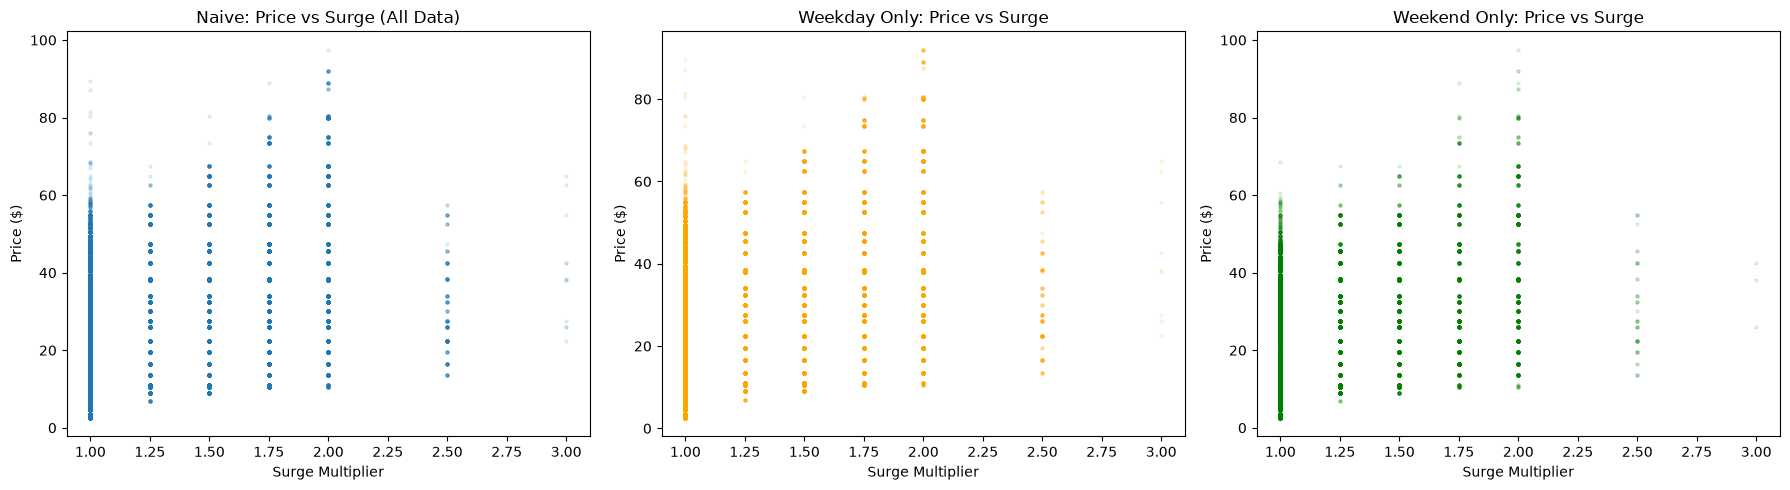

Correlation (all data): 0.24032501660706948
Correlation (weekday only): 0.24156911316147217
Correlation (weekend only): 0.23683819293469965


In [26]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Naive - price vs surge, whole dataset combined
axes[0].scatter(merged_df['surge_multiplier'], merged_df['price'], alpha=0.1, s=5)
axes[0].set_title('Naive: Price vs Surge (All Data)')
axes[0].set_xlabel('Surge Multiplier')
axes[0].set_ylabel('Price ($)')

# Plot 2: Weekday only
weekday_data = merged_df[merged_df['is_weekend'] == 0]
axes[1].scatter(weekday_data['surge_multiplier'], weekday_data['price'], alpha=0.1, s=5, color='orange')
axes[1].set_title('Weekday Only: Price vs Surge')
axes[1].set_xlabel('Surge Multiplier')
axes[1].set_ylabel('Price ($)')

# Plot 3: Weekend only
weekend_data = merged_df[merged_df['is_weekend'] == 1]
axes[2].scatter(weekend_data['surge_multiplier'], weekend_data['price'], alpha=0.1, s=5, color='green')
axes[2].set_title('Weekend Only: Price vs Surge')
axes[2].set_xlabel('Surge Multiplier')
axes[2].set_ylabel('Price ($)')

plt.tight_layout()
plt.savefig('../notebooks/confounding_check.png', dpi=150)
plt.show()

# Also print the actual correlation numbers, not just visual
print("Correlation (all data):", merged_df['surge_multiplier'].corr(merged_df['price']))
print("Correlation (weekday only):", weekday_data['surge_multiplier'].corr(weekday_data['price']))
print("Correlation (weekend only):", weekend_data['surge_multiplier'].corr(weekend_data['price']))

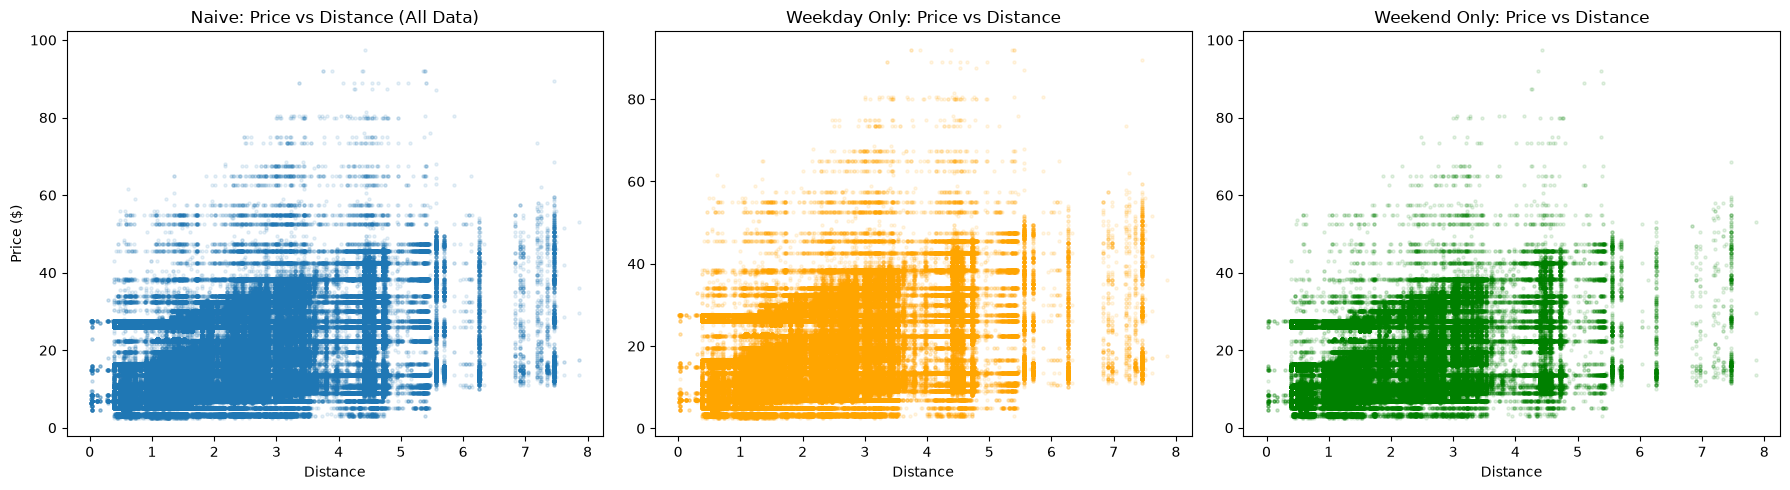

Correlation - distance vs price (all): 0.34508213043339614
Correlation - distance vs price (weekday): 0.34457507084913924
Correlation - distance vs price (weekend): 0.34649875744070546


In [28]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(merged_df['distance'], merged_df['price'], alpha=0.1, s=5)
axes[0].set_title('Naive: Price vs Distance (All Data)')
axes[0].set_xlabel('Distance')
axes[0].set_ylabel('Price ($)')

axes[1].scatter(weekday_data['distance'], weekday_data['price'], alpha=0.1, s=5, color='orange')
axes[1].set_title('Weekday Only: Price vs Distance')
axes[1].set_xlabel('Distance')

axes[2].scatter(weekend_data['distance'], weekend_data['price'], alpha=0.1, s=5, color='green')
axes[2].set_title('Weekend Only: Price vs Distance')
axes[2].set_xlabel('Distance')

plt.tight_layout()
plt.savefig('../notebooks/confounding_check_distance.png', dpi=150)
plt.show()

print("Correlation - distance vs price (all):", merged_df['distance'].corr(merged_df['price']))
print("Correlation - distance vs price (weekday):", weekday_data['distance'].corr(weekday_data['price']))
print("Correlation - distance vs price (weekend):", weekend_data['distance'].corr(weekend_data['price']))

In [29]:
merged_df.to_csv('../data/cab_cleaned_features.csv', index=False)
print("Saved! Shape:", merged_df.shape)

Saved! Shape: (635242, 28)


In [30]:
from sklearn.model_selection import train_test_split

# Select the features the model will learn from
feature_cols = [
    'distance', 'surge_multiplier', 'hour_of_day', 'day_of_week',
    'is_weekend', 'is_rush_hour', 'is_raining', 'cab_type_encoded', 'name_encoded'
]

X = merged_df[feature_cols]
y = merged_df['price']

# Split into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (508193, 9)
Test set size: (127049, 9)


In [31]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, r2_score

# Train the model
model = xgb.XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train)

# Predict on the test set (data the model has never seen)
y_pred = model.predict(X_test)

# Evaluate
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE: ${mae:.2f}")
print(f"R² Score: {r2:.4f}")

MAE: $1.16
R² Score: 0.9640


In [32]:
print("Correlation of surge_multiplier with price:", merged_df['surge_multiplier'].corr(merged_df['price']))

# Check feature importance from the trained model
import pandas as pd
importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print(importance)

Correlation of surge_multiplier with price: 0.24032501660706948
            feature  importance
8      name_encoded    0.691872
7  cab_type_encoded    0.153506
0          distance    0.085850
1  surge_multiplier    0.068069
5      is_rush_hour    0.000187
6        is_raining    0.000181
2       hour_of_day    0.000175
3       day_of_week    0.000160
4        is_weekend    0.000000


In [33]:
# Train a second model WITHOUT tier/cab_type — to isolate the effect of dynamic signals alone
dynamic_feature_cols = [
    'distance', 'surge_multiplier', 'hour_of_day', 'day_of_week',
    'is_weekend', 'is_rush_hour', 'is_raining'
]

X_dynamic = merged_df[dynamic_feature_cols]
y_dynamic = merged_df['price']

X_train_dyn, X_test_dyn, y_train_dyn, y_test_dyn = train_test_split(
    X_dynamic, y_dynamic, test_size=0.2, random_state=42
)

model_dynamic = xgb.XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42)
model_dynamic.fit(X_train_dyn, y_train_dyn)

y_pred_dyn = model_dynamic.predict(X_test_dyn)

mae_dyn = mean_absolute_error(y_test_dyn, y_pred_dyn)
r2_dyn = r2_score(y_test_dyn, y_pred_dyn)

print("=== Full Model (with tier + cab_type) ===")
print(f"MAE: ${mae:.2f}  |  R²: {r2:.4f}")

print("\n=== Dynamic-Only Model (distance + demand + weather + time) ===")
print(f"MAE: ${mae_dyn:.2f}  |  R²: {r2_dyn:.4f}")

# Feature importance for the dynamic-only model
importance_dyn = pd.DataFrame({
    'feature': dynamic_feature_cols,
    'importance': model_dynamic.feature_importances_
}).sort_values('importance', ascending=False)

print("\nDynamic-only model feature importance:")
print(importance_dyn)

=== Full Model (with tier + cab_type) ===
MAE: $1.16  |  R²: 0.9640

=== Dynamic-Only Model (distance + demand + weather + time) ===
MAE: $6.94  |  R²: 0.1766

Dynamic-only model feature importance:
            feature  importance
1  surge_multiplier    0.574405
0          distance    0.398886
2       hour_of_day    0.007947
3       day_of_week    0.006809
5      is_rush_hour    0.006394
6        is_raining    0.005559
4        is_weekend    0.000000


In [34]:
import shap

# Create the SHAP explainer for our trained full model
explainer = shap.TreeExplainer(model)

# Calculate SHAP values for a sample of the test set (full test set can be slow with 127K rows)
sample = X_test.sample(n=1000, random_state=42)
shap_values = explainer.shap_values(sample)

print("SHAP values shape:", shap_values.shape)
print("Sample shape:", sample.shape)

c:\Users\Paras\Desktop\dynamic-pricing-genai\dynamic-pricing-genai\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP values shape: (1000, 9)
Sample shape: (1000, 9)


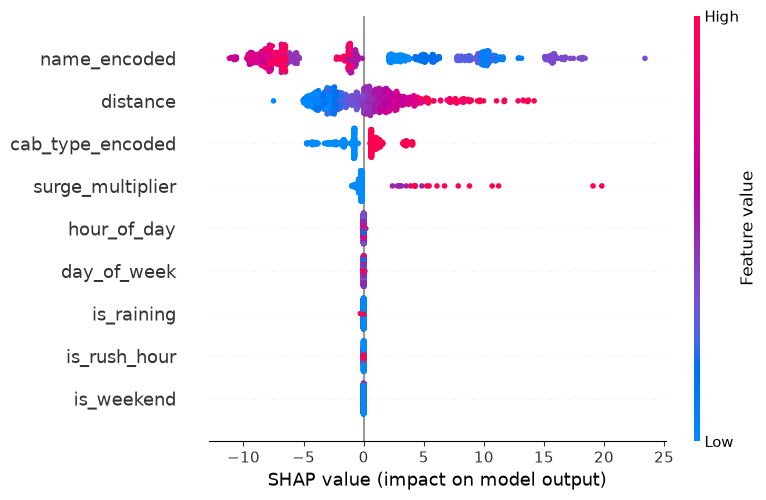

In [35]:
# Summary plot: shows which features matter most, and their range of impact
shap.summary_plot(shap_values, sample, show=False)
plt.tight_layout()
plt.savefig('../notebooks/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

In [36]:
def explain_prediction(row_index, X_data, shap_vals, base_value):
    """Get the top contributing features for a single prediction."""
    row_shap = shap_vals[row_index]
    feature_names = X_data.columns
    
    # Pair each feature with its SHAP contribution, sorted by absolute impact
    contributions = sorted(
        zip(feature_names, row_shap),
        key=lambda x: abs(x[1]),
        reverse=True
    )
    
    print(f"Base price (average): ${base_value:.2f}")
    print(f"Actual predicted price: ${base_value + row_shap.sum():.2f}\n")
    print("Top contributing factors:")
    for feature, contribution in contributions[:3]:
        direction = "increased" if contribution > 0 else "decreased"
        print(f"  {feature}: {direction} price by ${abs(contribution):.2f}")

# Try it on the first ride in our sample
explain_prediction(0, sample, shap_values, explainer.expected_value)

Base price (average): $16.54
Actual predicted price: $7.40

Top contributing factors:
  name_encoded: decreased price by $9.50
  distance: increased price by $2.37
  cab_type_encoded: decreased price by $1.71
